# Project 01 | Retail Banking Customer Churn Analysis
## Clarivance Analytics Group

**Analyst:** Esther Uzor
**Date:** April 2026
**Dataset:** Bank Customer Churn Prediction — Kaggle (CC0)
**Tools:** Python · Pandas · Scikit-learn · Seaborn

---

### Objective
This notebook delivers a full 5-tier churn analysis for a mid-size
UK retail bank experiencing accelerating customer attrition.

1. **Tier 1 — Descriptive:** Visualise churn patterns by segment
2. **Tier 2 — Diagnostic:** Identify root-cause factor combinations
3. **Tier 3 — Predictive:** Build churn probability model (LR + RF)
4. **Tier 4 — Prescriptive:** Score every customer and export risk register
5. **Tier 5 — Narrative:** Quantify business impact for C-suite

---

### Key Pre-Findings from SQL Analysis
SQL audit and diagnostic queries (Scripts 01–03) confirmed:
- Overall churn rate: **20.37%** (2,037 of 10,000 customers)
- Germany churns at **32.44%** — 2× the France/Spain rate
- 55–64 age band has the highest churn rate at **49.83%**
- 3 and 4-product customers churn at 82.71% and 100% respectively
- Inactive members churn at **1.88×** the rate of active members
- Highest-risk segment: Germany + 55–64 + Inactive + 1 product = **96% churn**
- Churned customers hold 25% higher average balance (£91,108 vs £72,745)
- £185.6M in total balance at risk from churned customers

## 1. Environment Setup
All libraries imported in a single cell, grouped by purpose

In [1]:
# ── Data manipulation ────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Machine learning ─────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# ── Configuration ────────────────────────────────────────────
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

# Clarivance brand palette — applied to ALL visuals
NAVY    = '#0D1F3C'
TEAL    = '#00B4A6'
GOLD    = '#F5A623'
RED     = '#E03E3E'
GREEN   = '#2ECC8F'
GREY    = '#8A9BB0'

PALETTE = [TEAL, NAVY, GOLD, RED, GREEN, GREY]

print("✅ Environment ready.")
print(f"Pandas: {pd.__version__} | NumPy: {np.__version__}")

✅ Environment ready.
Pandas: 3.0.2 | NumPy: 2.4.4


## 2. Data Loading
Loading the cleaned CSV produced by DuckDB Script 02.

Raw row count confirmed at 10,000 with zero nulls at audit stage.

In [3]:
import subprocess
from pathlib import Path

# Use Git to locate the repo root — works on any machine,
# any OS, regardless of where the repo is cloned
result = subprocess.run(
    ['git', 'rev-parse', '--show-toplevel'],
    capture_output=True,
    text=True
)

REPO_ROOT    = Path(result.stdout.strip())
PROJECT_ROOT = REPO_ROOT / 'project-01-finance-retail-churn'
DATA_PATH    = PROJECT_ROOT / 'data' / 'cleaned' / 'bank_churn_clean.csv'
OUTPUTS_PATH = PROJECT_ROOT / 'outputs'

# Verify before loading
print(f"Repo root:    {REPO_ROOT}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Data path:    {DATA_PATH}")
print(f"Data exists:  {DATA_PATH.exists()}")

df = pd.read_csv(DATA_PATH)

print(f"\nShape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
df.head()

Repo root:    C:\Users\esther.uzor\OneDrive - Accenture\Documents\data-analytics-2026
Project root: C:\Users\esther.uzor\OneDrive - Accenture\Documents\data-analytics-2026\project-01-finance-retail-churn
Data path:    C:\Users\esther.uzor\OneDrive - Accenture\Documents\data-analytics-2026\project-01-finance-retail-churn\data\cleaned\bank_churn_clean.csv
Data exists:  True

Shape: (10000, 16)

Columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'age_band', 'balance_tier', 'credit_band', 'engagement_score', 'tenure_band']

Data types:
CreditScore           int64
Geography               str
Gender                  str
Age                   int64
Tenure                int64
Balance             float64
NumOfProducts         int64
HasCrCard             int64
IsActiveMember        int64
EstimatedSalary     float64
Exited                int64
age_band                str
balance_tier            

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,age_band,balance_tier,credit_band,engagement_score,tenure_band
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,35-44,Zero Balance,Good,3,New (0-2 yrs)
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,35-44,Mid Balance,Good,2,New (0-2 yrs)
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,35-44,Premium Balance,Fair,3,Established (6-8 yrs)
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,35-44,Zero Balance,Good,2,New (0-2 yrs)
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,35-44,High Balance,Excellent,3,New (0-2 yrs)


###3. Data Quality Veerification
Confirming the cleaned data matches the SQL audit expectations

Any discrepancy here would flag an issue in the cleaning pipeline

In [4]:
# Null check — expect 0 after SQL cleaning
print("Null counts per column:")
print(df.isnull().sum())

# Class balance confirmation
print(f"\nTarget variable distribution:")
print(df['Exited'].value_counts())
print(f"\nChurn rate: {df['Exited'].mean()*100:.2f}%")
print(f"Class imbalance ratio: {round(df['Exited'].value_counts()[0] / df['Exited'].value_counts()[1], 2)}:1")

# Summary statistics
df.describe().round(2)

Null counts per column:
CreditScore         0
Geography           0
Gender              0
Age                 0
Tenure              0
Balance             0
NumOfProducts       0
HasCrCard           0
IsActiveMember      0
EstimatedSalary     0
Exited              0
age_band            0
balance_tier        0
credit_band         0
engagement_score    0
tenure_band         0
dtype: int64

Target variable distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.37%
Class imbalance ratio: 3.91:1


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,engagement_score
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0,10000.00
mean,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2,2.71
std,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4,0.85
min,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0,1.00
25%,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0,2.00
50%,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0,3.00
75%,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0,3.00
max,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0,4.00


## 4. Exploratory Data Analysis

### Visualisation 1 — Overall Churn Rate
Establishes the headline metric before any segmentation.
SQL confirmed 20.37% overall churn rate.
Churned customers hold a 25% higher average balance (£91,108)
than retained customers (£72,745) — the customers leaving
are disproportionately the higher-value ones.

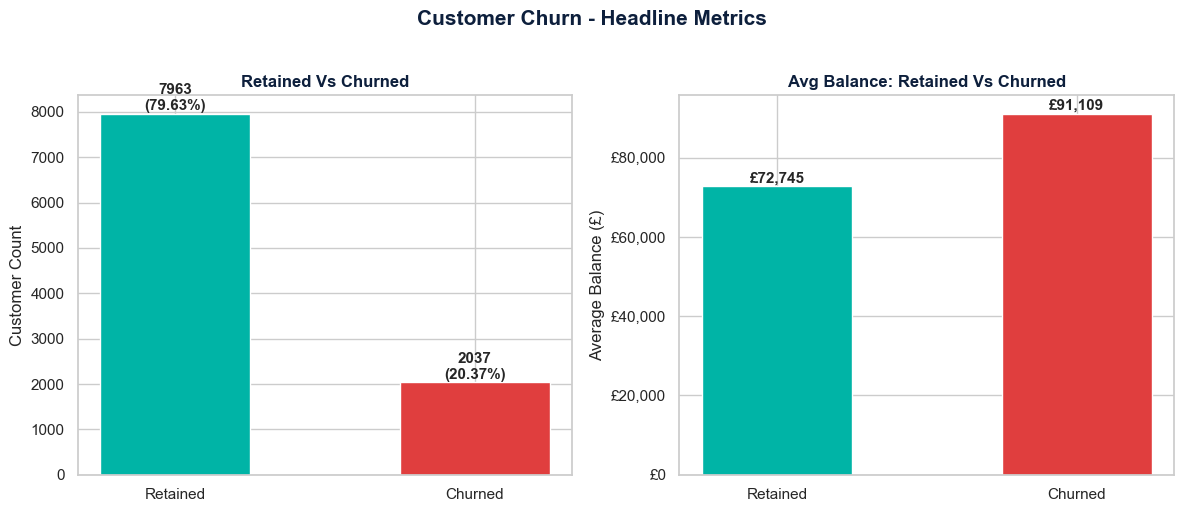

Saved: viz_01_headline_metrics.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Customer Churn - Headline Metrics',
             fontsize=15, fontweight='bold', color=NAVY, y=1.02)

#Left: Churn rate bar
churn_counts = df['Exited'].value_counts()
labels = ['Retained', 'Churned']
colors = [TEAL, RED]
bars = axes[0].bar(labels, churn_counts, color=colors, width=0.5)
axes[0].set_title('Retained Vs Churned', fontweight='bold', color=NAVY)
axes[0].set_ylabel('Customer Count')
for bar, val, pct in zip(bars, churn_counts.values,
                        [79.63, 20.37]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 80,
                 f'{val}\n({pct}%)',
                 ha='center', fontweight='bold', fontsize=11)

#Right: Avg balance comparison
avg_bal = df.groupby('Exited')['Balance'].mean()
bars2 = axes[1].bar(['Retained', 'Churned'],
                    avg_bal.values, color=[TEAL, RED], width=0.5)
axes[1].set_title("Avg Balance: Retained Vs Churned"
                  , fontweight='bold', color=NAVY)
axes[1].set_ylabel('Average Balance (£)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for bar, val in zip(bars2, avg_bal.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1000,
                 f'£{val:,.0f}',
                 ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'viz_01_headline_metrics.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_01_headline_metrics.png")

### Visualisation 2 — Churn Rate by Geography
SQL confirmed Germany at 32.44% — 2× the France/Spain rate.
Germany also holds the highest average balance at £119,730,
making it the highest-value geographic risk.
Total balance at risk in Germany alone: £97.9M.

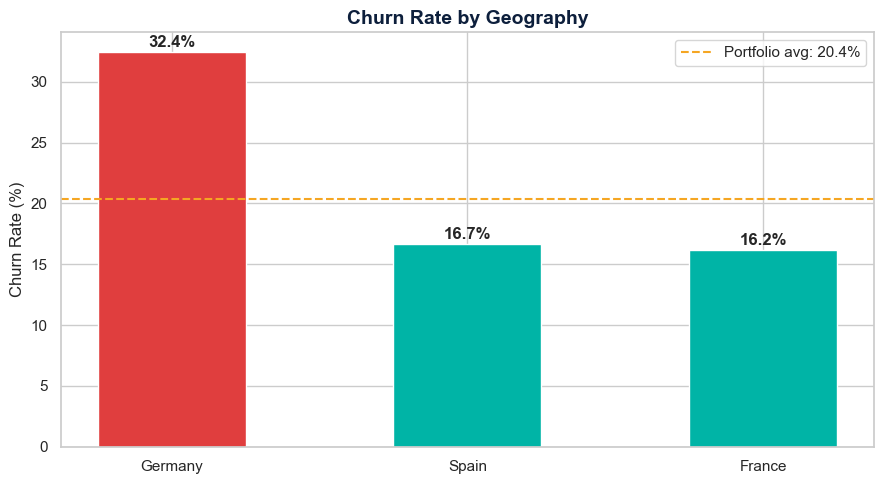

Saved: viz_02_churn_by_geography.png


In [9]:
geo_churn = (df.groupby('Geography')['Exited']
               .agg(['mean', 'count'])
               .reset_index())
geo_churn.columns = ['Geography', 'churn_rate', 'customers']
geo_churn['churn_rate'] = geo_churn['churn_rate'] * 100
geo_churn = geo_churn.sort_values('churn_rate', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [RED if g == 'Germany' else TEAL
          for g in geo_churn['Geography']]
bars = ax.bar(geo_churn['Geography'],
              geo_churn['churn_rate'],
              color=colors, width=0.5)

# Portfolio average line
avg = df['Exited'].mean() * 100
ax.axhline(avg, color=GOLD, linestyle='--',
           linewidth=1.5, label=f'Portfolio avg: {avg:.1f}%')

ax.set_title('Churn Rate by Geography',
             fontsize=14, fontweight='bold', color=NAVY)
ax.set_ylabel('Churn Rate (%)')
ax.legend()

for bar, val in zip(bars, geo_churn['churn_rate']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4,
            f'{val:.1f}%',
            ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'viz_02_churn_by_geography.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_02_churn_by_geography.png")




### Visualisation 3 — Churn Rate by Age Band
SQL revealed 55–64 as the highest churn band at 49.83%,
closely followed by 45–54 at 48.15%.
These two bands combined represent the critical at-risk cohort
despite the 35–44 band being the largest by volume (39.81%).


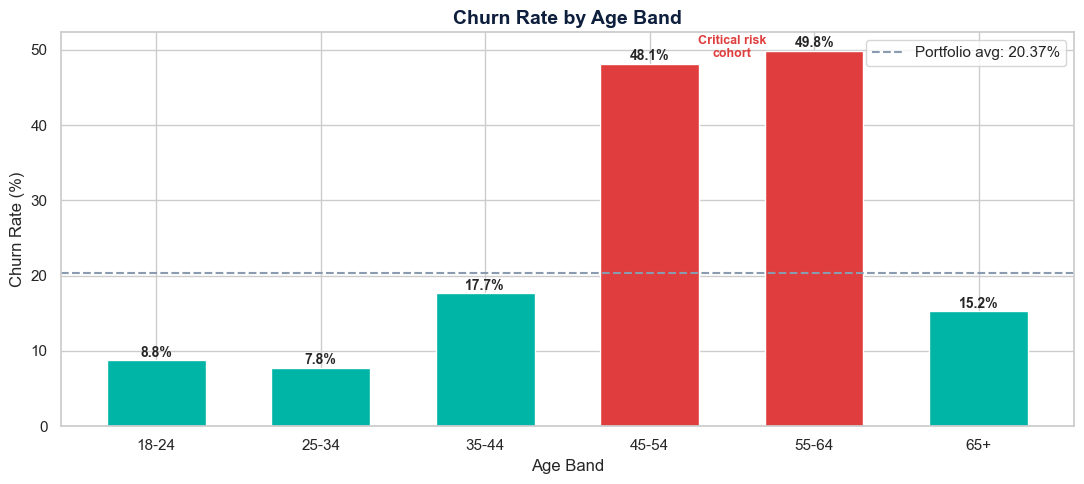

Saved: viz_03_churn_by_age.png


In [11]:
age_order = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']
age_churn = (df.groupby('age_band')['Exited']
               .mean()
               .reindex(age_order) * 100)

fig, ax = plt.subplots(figsize=(11, 5))
colors = [RED if v >= 40 else GOLD if v >= 20 else TEAL
          for v in age_churn.values]
bars = ax.bar(age_churn.index, age_churn.values,
              color=colors, width=0.6)

ax.axhline(20.37, color=GREY, linestyle='--',
           linewidth=1.5, label='Portfolio avg: 20.37%')
ax.set_title('Churn Rate by Age Band',
             fontsize=14, fontweight='bold', color=NAVY)
ax.set_ylabel('Churn Rate (%)')
ax.set_xlabel('Age Band')
ax.legend()

for bar, val in zip(bars, age_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%',
            ha='center', fontsize=10, fontweight='bold')

# Annotation for highest risk bands
ax.annotate('Critical risk\ncohort',
            xy=(3.5, 49), fontsize=9,
            color=RED, fontweight='bold', ha='center')

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'viz_03_churn_by_age.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_03_churn_by_age.png")

### Visualisation 4 — Churn Rate by Number of Products
SQL revealed a non-linear and alarming pattern:
- 1 product: 27.71% churn — elevated but manageable
- 2 products: 7.58% churn — strong retention signal
- 3 products: 82.71% churn — critical anomaly (266 customers)
- 4 products: 100% churn — every customer with 4 products churned (60 customers)

The 3–4 product anomaly likely reflects over-selling behaviour —
customers sold products they did not need or want.

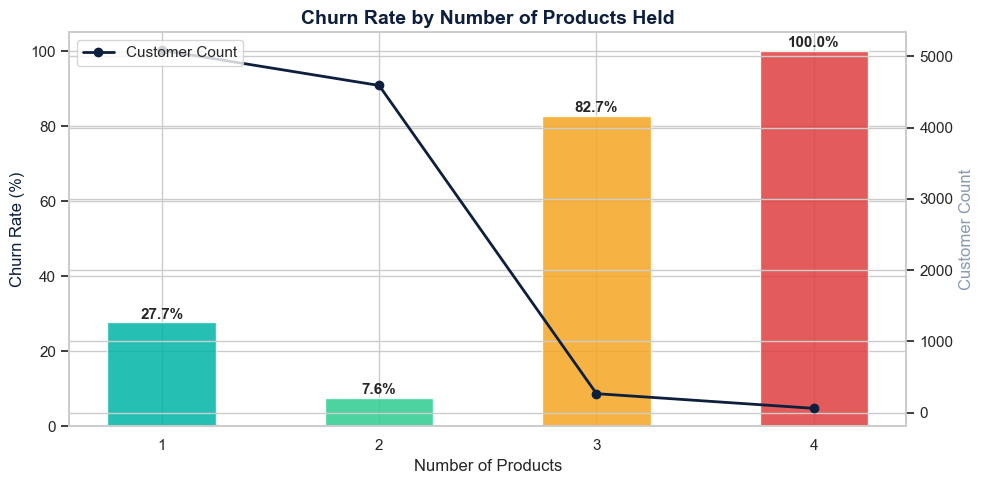

Saved: viz_04_churn_by_products.png


In [12]:
prod_churn = (df.groupby('NumOfProducts')['Exited']
                .agg(['mean', 'count'])
                .reset_index())
prod_churn.columns = ['Products', 'churn_rate', 'customers']
prod_churn['churn_rate'] = prod_churn['churn_rate'] * 100

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

colors = [TEAL, GREEN, GOLD, RED]
bars = ax1.bar(prod_churn['Products'].astype(str),
               prod_churn['churn_rate'],
               color=colors, alpha=0.85, width=0.5)
ax2.plot(prod_churn['Products'].astype(str),
         prod_churn['customers'],
         color=NAVY, marker='o', linewidth=2,
         label='Customer Count')

ax1.set_title('Churn Rate by Number of Products Held',
              fontsize=14, fontweight='bold', color=NAVY)
ax1.set_xlabel('Number of Products')
ax1.set_ylabel('Churn Rate (%)', color=NAVY)
ax2.set_ylabel('Customer Count', color=GREY)
ax2.legend(loc='upper left')

for bar, val in zip(bars, prod_churn['churn_rate']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{val:.1f}%',
             ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH /'viz_04_churn_by_products.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_04_churn_by_products.png")

### Visualisation 5 — Active vs Inactive Member Churn
IsActiveMember is the strongest single behavioural predictor.
SQL confirmed inactive members churn at 1.88× the rate of
active members (26.85% vs 14.27%).
Reactivation campaigns targeting the 4,849 inactive members
represent a high-ROI retention lever.

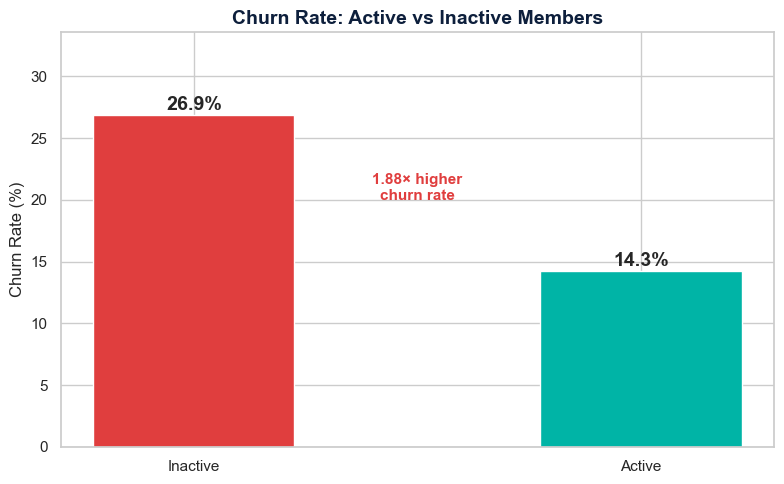

Saved: viz_05_active_vs_inactive.png


In [13]:
active_churn = (df.groupby('IsActiveMember')['Exited']
                  .mean() * 100)
labels = ['Inactive', 'Active']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, active_churn.values,
              color=[RED, TEAL], width=0.45)
ax.set_title('Churn Rate: Active vs Inactive Members',
             fontsize=14, fontweight='bold', color=NAVY)
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, active_churn.max() * 1.25)

for bar, val in zip(bars, active_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4,
            f'{val:.1f}%',
            ha='center', fontsize=14, fontweight='bold')

# Multiplier annotation
ax.annotate('1.88× higher\nchurn rate',
            xy=(0.5, 20), fontsize=11,
            color=RED, fontweight='bold', ha='center')

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'viz_05_active_vs_inactive.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_05_active_vs_inactive.png")

### Visualisation 6 — Engagement Score vs Churn Rate
The composite engagement score (0–4) shows a clean inverse
relationship with churn — validating the engineered feature
before it enters the predictive model.

Score 1 customers churn at 34.54% vs 9.12% for score 4.
This confirms the feature will carry predictive weight in the model.

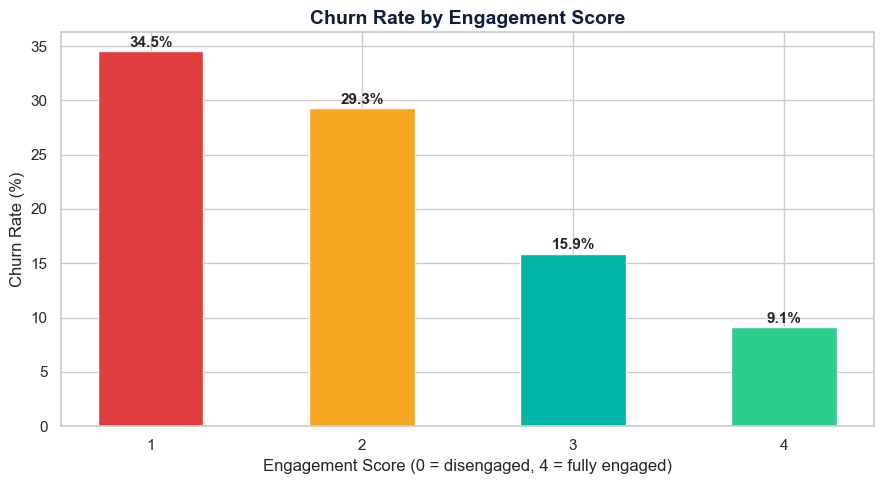

Saved: viz_06_engagement_vs_churn.png


In [15]:
eng_churn = (df.groupby('engagement_score')['Exited']
               .mean() * 100)

fig, ax = plt.subplots(figsize=(9, 5))
colors = [RED, GOLD, TEAL, GREEN]
bars = ax.bar(eng_churn.index.astype(str),
              eng_churn.values,
              color=colors, width=0.5)
ax.set_title('Churn Rate by Engagement Score',
             fontsize=14, fontweight='bold', color=NAVY)
ax.set_xlabel('Engagement Score (0 = disengaged, 4 = fully engaged)')
ax.set_ylabel('Churn Rate (%)')

for bar, val in zip(bars, eng_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4,
            f'{val:.1f}%',
            ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'viz_06_engagement_vs_churn.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: viz_06_engagement_vs_churn.png")

### Visualisation 7 — Correlation Heatmap
Identifies which numerical features correlate most strongly
with the Exited target variable.
This directly informs feature selection for the predictive model.

Age is expected to show the strongest positive correlation
based on SQL findings (55–64 at 49.83% churn).

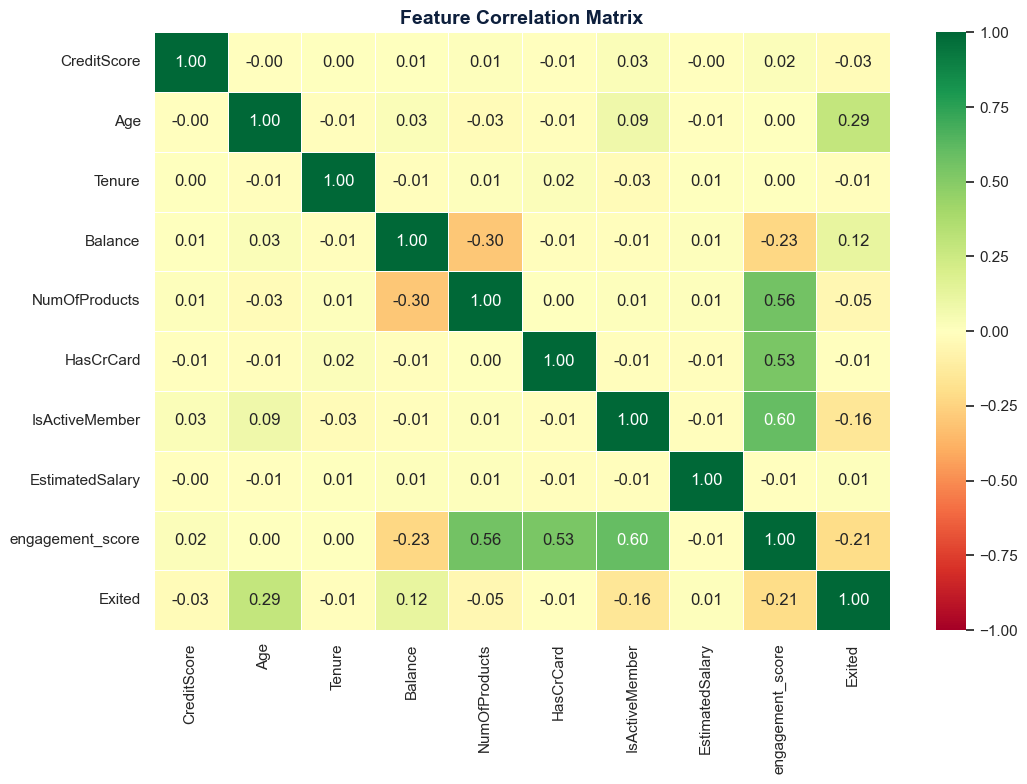


Top correlations with Exited (churn):
Exited              1.000000
Age                 0.285323
Balance             0.118533
EstimatedSalary     0.012097
HasCrCard          -0.007138
Tenure             -0.014001
CreditScore        -0.027094
NumOfProducts      -0.047820
IsActiveMember     -0.156128
engagement_score   -0.205772


In [16]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance',
                'NumOfProducts', 'HasCrCard', 'IsActiveMember',
                'EstimatedSalary', 'engagement_score', 'Exited']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax)
ax.set_title('Feature Correlation Matrix',
             fontsize=14, fontweight='bold', color=NAVY)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH / 'viz_07_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTop correlations with Exited (churn):")
print(corr['Exited'].sort_values(ascending=False).to_string())